# Support Vector Machines (SVM) Classifier

Support Vector Machines (SVM) are a powerful class of supervised machine learning algorithms used for classification, regression, and outlier detection. The fundamental concept behind SVM is to find an optimal decision boundary (hyperplane) that separates classes in a multi-dimensional space while maximizing the geometric margin between the boundary and the closest data points of any class.

In this notebook, we will cover:
1. **Mathematical Foundations**:
   - The optimization objective for linear, hard-margin, and soft-margin SVMs.
   - Dual formulation and support vectors.
   - The Kernel Trick for non-linear decision boundaries.
2. **Implementation from Scratch**:
   - Implementing a Linear SVM classifier using subgradient descent on Hinge Loss in pure Python/NumPy.
3. **Scikit-Learn Integration**:
   - Implementing linear and kernel SVMs using `scikit-learn`.
4. **Visualizations**:
   - Plotting decision boundaries, margins, and support vectors in 2D.
5. **Hyperparameter Analysis**:
   - Exploring the behavior of regularizer $C$ and RBF kernel parameter $\gamma$.

## 1. Mathematical Formulation

### 1.1 Linear SVM (Hard-Margin)
Let the training dataset be denoted as $\mathcal{D} = \{(x_1, y_1), (x_2, y_2), \dots, (x_n, y_n)\}$, where $x_i \in \mathbb{R}^d$ and $y_i \in \{-1, +1\}$.

A linear decision boundary is defined by a hyperplane:
$$w^T x + b = 0$$
where $w \in \mathbb{R}^d$ is the weight vector normal to the hyperplane, and $b \in \mathbb{R}$ is the bias. The decision function is given by:
$$f(x) = \text{sign}(w^T x + b)$$

For a linearly separable dataset, we can define the scale of $w$ and $b$ such that the closest points (support vectors) lie on the hyperplanes:
$$w^T x_i + b = +1 \quad \text{if } y_i = +1$$
$$w^T x_i + b = -1 \quad \text{if } y_i = -1$$

Thus, for all training examples:
$$y_i (w^T x_i + b) \ge 1, \quad \forall i \in \{1, \dots, n\}$$

The distance from the hyperplane to any support vector is $\frac{1}{\|w\|_2}$. The total margin is the sum of the distances from the decision boundary to the nearest positive and negative points, which is:
$$\text{Margin} = \frac{2}{\|w\|_2}$$

To maximize the margin, we must minimize $\|w\|_2$, which is mathematically equivalent to minimizing $\frac{1}{2}\|w\|_2^2$. This yields the **primal hard-margin optimization problem**:
$$\min_{w, b} \frac{1}{2} \|w\|_2^2 \quad \text{subject to} \quad y_i(w^T x_i + b) \ge 1, \quad \forall i$$

---

### 1.2 Soft-Margin SVM
If the data is not perfectly separable, we introduce non-negative slack variables $\xi_i \ge 0$ for each data point to allow constraint violations. The optimization problem becomes:
$$\min_{w, b, \xi} \frac{1}{2} \|w\|_2^2 + C \sum_{i=1}^n \xi_i$$
$$\text{subject to} \quad y_i(w^T x_i + b) \ge 1 - \xi_i, \quad \xi_i \ge 0 \quad \forall i$$
where $C > 0$ is a regularization hyperparameter:
- A **large $C$** penalizes violations heavily, leading to a narrower margin but fewer classification mistakes on the training set (potential overfitting).
- A **small $C$** allows more violations, leading to a wider margin but potentially more misclassifications (potential underfitting).

Using the Hinge Loss function, we can rewrite the primal soft-margin objective in an unconstrained form:
$$\min_{w, b} \left[ \frac{1}{2} \|w\|_2^2 + C \sum_{i=1}^n \max\left(0, 1 - y_i(w^T x_i + b)\right) \right]$$

---

### 1.3 Dual Formulation
Using Lagrange multipliers $\alpha_i \ge 0$, the primal optimization problem can be transformed into its **Wolfe Dual** representation:
$$\max_{\alpha} \left[ \sum_{i=1}^n \alpha_i - \frac{1}{2} \sum_{i=1}^n \sum_{j=1}^n \alpha_i \alpha_j y_i y_j (x_i^T x_j) \right]$$
$$\text{subject to} \quad \sum_{i=1}^n \alpha_i y_i = 0 \quad \text{and} \quad 0 \le \alpha_i \le C, \quad \forall i$$

The solution for $w$ is a linear combination of the training points:
$$w = \sum_{i=1}^n \alpha_i y_i x_i$$
The points with $\alpha_i > 0$ are the **Support Vectors**. Only these points determine the decision boundary.

---

### 1.4 The Kernel Trick
If the data is non-linearly separable, we map the input features to a higher-dimensional space $\Phi(x)$. The dual formulation depends only on the dot products of the feature vectors: $\Phi(x_i)^T \Phi(x_j)$.
We can define a kernel function $K(x_i, x_j) = \Phi(x_i)^T \Phi(x_j)$ to compute this inner product directly in the input space, avoiding the explicit calculation of high-dimensional coordinates.

Common kernel functions include:
1. **Linear**: $K(x_i, x_j) = x_i^T x_j$
2. **Polynomial**: $K(x_i, x_j) = (x_i^T x_j + c)^d$
3. **Radial Basis Function (RBF)**: $K(x_i, x_j) = \exp\left(-\gamma \|x_i - x_j\|_2^2\right)$

## 2. Setup and Imports

Let's begin by importing the necessary scientific libraries for computation, model training, evaluation, and visualization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

## 3. Custom Linear SVM Implementation (Hinge Loss Minimization)

To gain a deep understanding of SVM, we implement a linear soft-margin SVM from scratch. We minimize the unconstrained Hinge Loss objective:
$$\mathcal{L}(w, b) = \frac{1}{2} \|w\|_2^2 + \frac{C}{n} \sum_{i=1}^n \max\left(0, 1 - y_i(w^T x_i + b)\right)$$

We use subgradient descent to optimize the parameters $w$ and $b$. The subgradients with respect to $w$ and $b$ for a single sample $(x_i, y_i)$ are:
- If $y_i(w^T x_i + b) \ge 1$:
  $$\frac{\partial \mathcal{L}_i}{\partial w} = w, \quad \frac{\partial \mathcal{L}_i}{\partial b} = 0$$
- If $y_i(w^T x_i + b) < 1$:
  $$\frac{\partial \mathcal{L}_i}{\partial w} = w - C y_i x_i, \quad \frac{\partial \mathcal{L}_i}{\partial b} = -C y_i$$

In [2]:
class LinearSVMFromScratch:
    """
    Linear Support Vector Machine (SVM) Classifier trained using Hinge Loss Subgradient Descent.
    """
    def __init__(self, C=1.0, learning_rate=0.001, epochs=1000):
        self.C = C
        self.lr = learning_rate
        self.epochs = epochs
        self.w = None
        self.b = None

    def fit(self, X, y):
        # Convert class labels to {-1, 1} if they are {0, 1}
        y_transformed = np.where(y <= 0, -1, 1)
        
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0.0

        for epoch in range(self.epochs):
            for idx, x_i in enumerate(X):
                condition = y_transformed[idx] * (np.dot(x_i, self.w) + self.b) >= 1
                if condition:
                    # Parameter update when condition is met
                    dw = self.w
                    db = 0
                else:
                    # Parameter update when boundary/margin condition is violated
                    dw = self.w - self.C * y_transformed[idx] * x_i
                    db = -self.C * y_transformed[idx]
                
                # Apply updates
                self.w -= self.lr * dw
                self.b -= self.lr * db

    def decision_function(self, X):
        return np.dot(X, self.w) + self.b

    def predict(self, X):
        return np.where(self.decision_function(X) >= 0, 1, 0)

## 4. Verification on a Linearly Separable Dataset

Let's generate a linearly separable 2D dataset and compare our scratch implementation with `scikit-learn`'s `SVC` model.

In [3]:
# Generate synthetic linearly separable dataset
X, y = datasets.make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=1.2)

# Standardize features for faster convergence
X_std = (X - X.mean(axis=0)) / X.std(axis=0)

# Split dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_std, y, test_size=0.2, random_state=42)

# Train custom model
scratch_svm = LinearSVMFromScratch(C=10.0, learning_rate=0.001, epochs=2000)
scratch_svm.fit(X_train, y_train)
scratch_preds = scratch_svm.predict(X_test)

# Train scikit-learn model
sklearn_svm = SVC(kernel='linear', C=10.0)
sklearn_svm.fit(X_train, y_train)
sklearn_preds = sklearn_svm.predict(X_test)

print(f"Scratch SVM Accuracy: {accuracy_score(y_test, scratch_preds) * 100:.2f}%")
print(f"Sklearn SVM Accuracy: {accuracy_score(y_test, sklearn_preds) * 100:.2f}%")
print("\nScratch weights (w):", scratch_svm.w, "bias (b):", scratch_svm.b)
print("Sklearn weights (w):", sklearn_svm.coef_[0], "bias (b):", sklearn_svm.intercept_[0])

Scratch SVM Accuracy: 100.00%
Sklearn SVM Accuracy: 100.00%

Scratch weights (w): [ 0.82171571 -0.58067734] bias (b): 0.07
Sklearn weights (w): [ 1.05315628 -0.58781925] bias (b): 0.012561555822448466


## 5. Visualizing the Decision Boundary and Margins

A key visual aspect of SVM is the margin. Let's plot the decision boundary, the margin lines (parallel hyperplanes), and identify the support vectors.

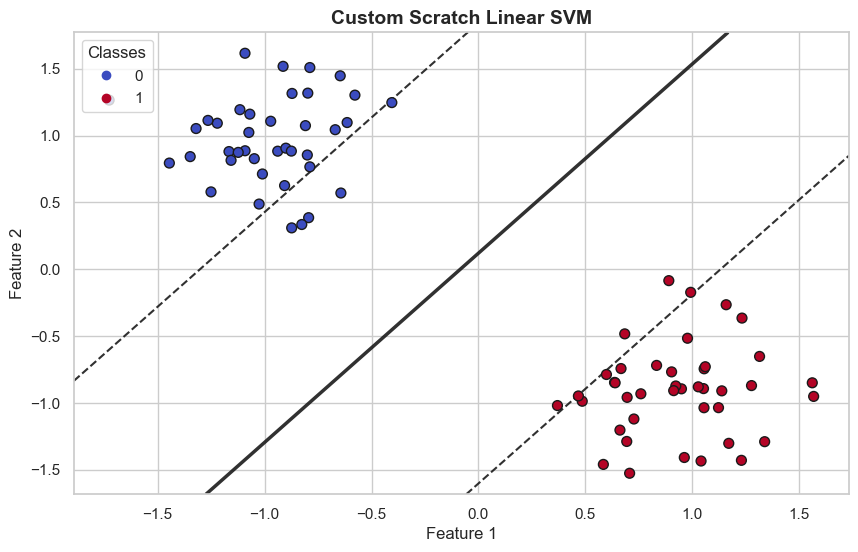

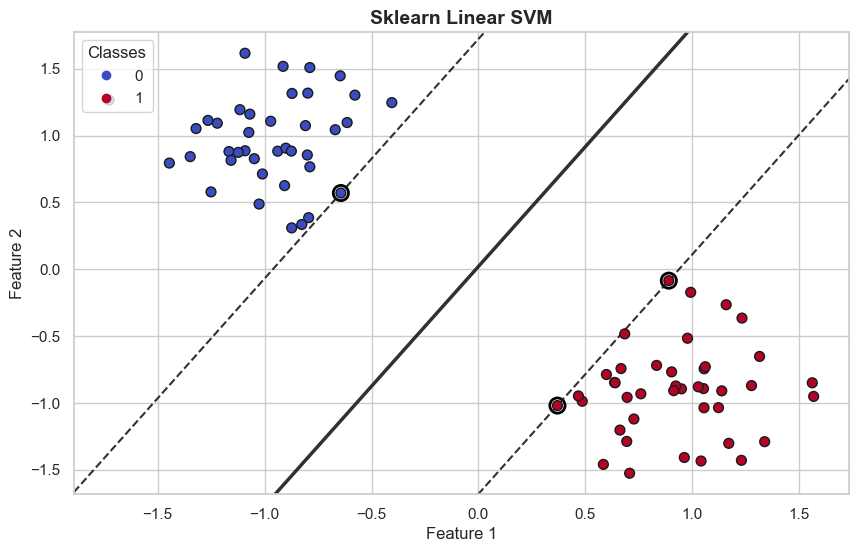

In [4]:
def plot_svm_decision_boundary(model, X, y, title="SVM Decision Boundary"):
    """
    Plots the decision boundary, margin hyperplanes, and data points.
    Works for both scikit-learn SVC and custom SVM models.
    """
    plt.figure(figsize=(10, 6))
    
    # Scatter plot of training points
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=50, zorder=3)
    
    # Create meshgrid to plot boundary contours
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    
    # Compute decision boundary values
    if hasattr(model, 'decision_function'):
        Z = model.decision_function(xy).reshape(XX.shape)
        # Identify support vectors if sklearn model
        if hasattr(model, 'support_vectors_'):
            sv = model.support_vectors_
            plt.scatter(sv[:, 0], sv[:, 1], s=120, facecolors='none', edgecolors='black', 
                        linewidths=2, label='Support Vectors', zorder=2)
    else:
        # Use our custom SVM's decision function
        Z = model.decision_function(xy).reshape(XX.shape)
        
    # Plot decision boundary (Z=0) and margins (Z=-1, Z=1)
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.9,
               linestyles=['--', '-', '--'], linewidths=[1.5, 2.5, 1.5])
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Feature 1', fontsize=12)
    plt.ylabel('Feature 2', fontsize=12)
    plt.legend(*scatter.legend_elements(), title="Classes", loc='upper left')
    plt.show()

# Visualize custom SVM decision boundary
plot_svm_decision_boundary(scratch_svm, X_train, y_train, title="Custom Scratch Linear SVM")

# Visualize Sklearn SVM decision boundary (which highlights support vectors)
plot_svm_decision_boundary(sklearn_svm, X_train, y_train, title="Sklearn Linear SVM")

## 6. Non-linear SVM and the Kernel Trick

Real-world datasets are rarely linearly separable. We can use the Kernel Trick to project the data into a higher-dimensional space where it becomes linearly separable.
Let's generate a non-linear dataset (interlocking half-moons) and test different kernels: Linear vs. Radial Basis Function (RBF).

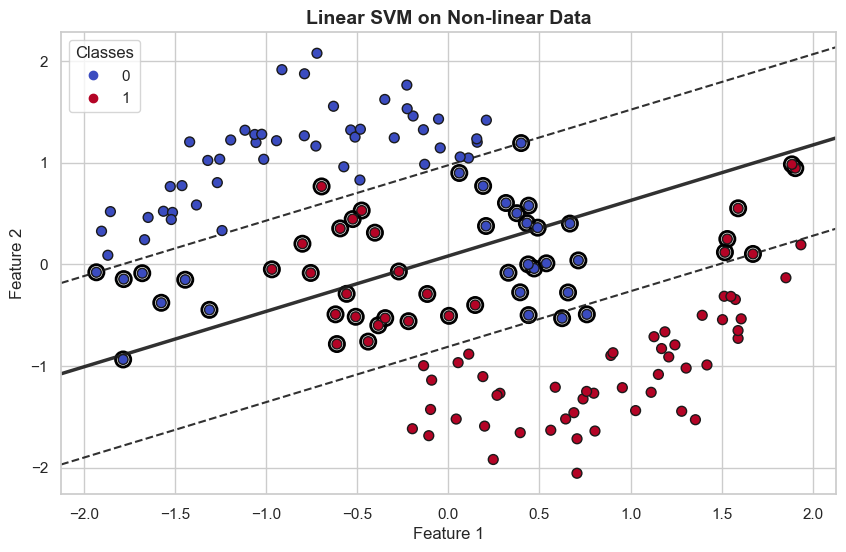

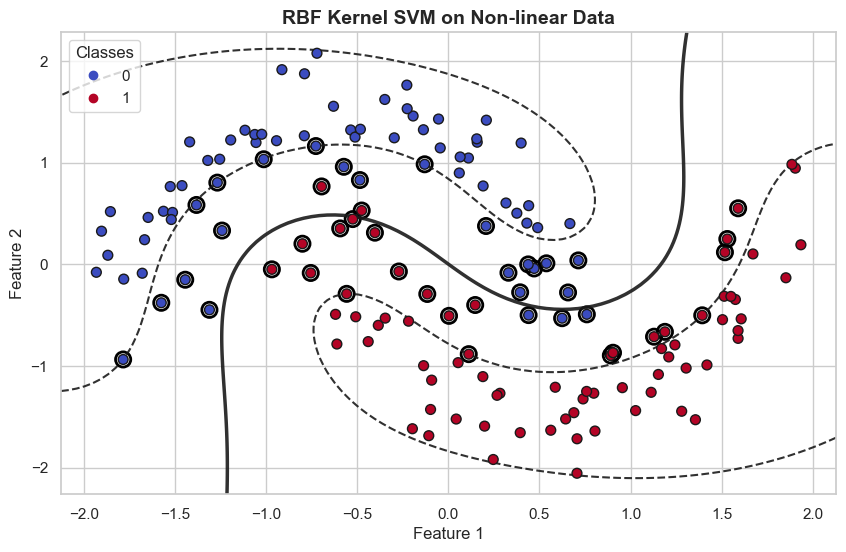

In [5]:
# Generate a non-linearly separable dataset
X_moon, y_moon = datasets.make_moons(n_samples=150, noise=0.15, random_state=42)

# Standardize
X_moon_std = (X_moon - X_moon.mean(axis=0)) / X_moon.std(axis=0)

# Train linear kernel on non-linear data
svm_linear = SVC(kernel='linear', C=1.0)
svm_linear.fit(X_moon_std, y_moon)

# Train RBF kernel on non-linear data
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_rbf.fit(X_moon_std, y_moon)

# Plot both models
plot_svm_decision_boundary(svm_linear, X_moon_std, y_moon, title="Linear SVM on Non-linear Data")
plot_svm_decision_boundary(svm_rbf, X_moon_std, y_moon, title="RBF Kernel SVM on Non-linear Data")

## 7. Hyperparameter Analysis: Tuning $C$ and $\gamma$

The performance of an RBF Kernel SVM depends strongly on two hyperparameters:
1. **$C$ (Regularization Parameter)**: Controls the trade-off between decision boundary smoothness and classification accuracy.
2. **$\gamma$ (Gamma)**: Controls the radius of influence of individual training points.
   - High $\gamma$ means a single point's influence is localized. The boundary gets wiggly and tight around data clusters.
   - Low $\gamma$ means a single point has a broad influence, leading to smoother, simpler boundaries.

Let's visualize the impact of varying both parameters.

<>:36: SyntaxWarning: invalid escape sequence '\g'
<>:36: SyntaxWarning: invalid escape sequence '\g'
D:\Temp\ipykernel_11252\3602667907.py:36: SyntaxWarning: invalid escape sequence '\g'
  ax.set_title(f"RBF Kernel: C={C}, $\gamma$={gamma}", fontsize=12, fontweight='bold')


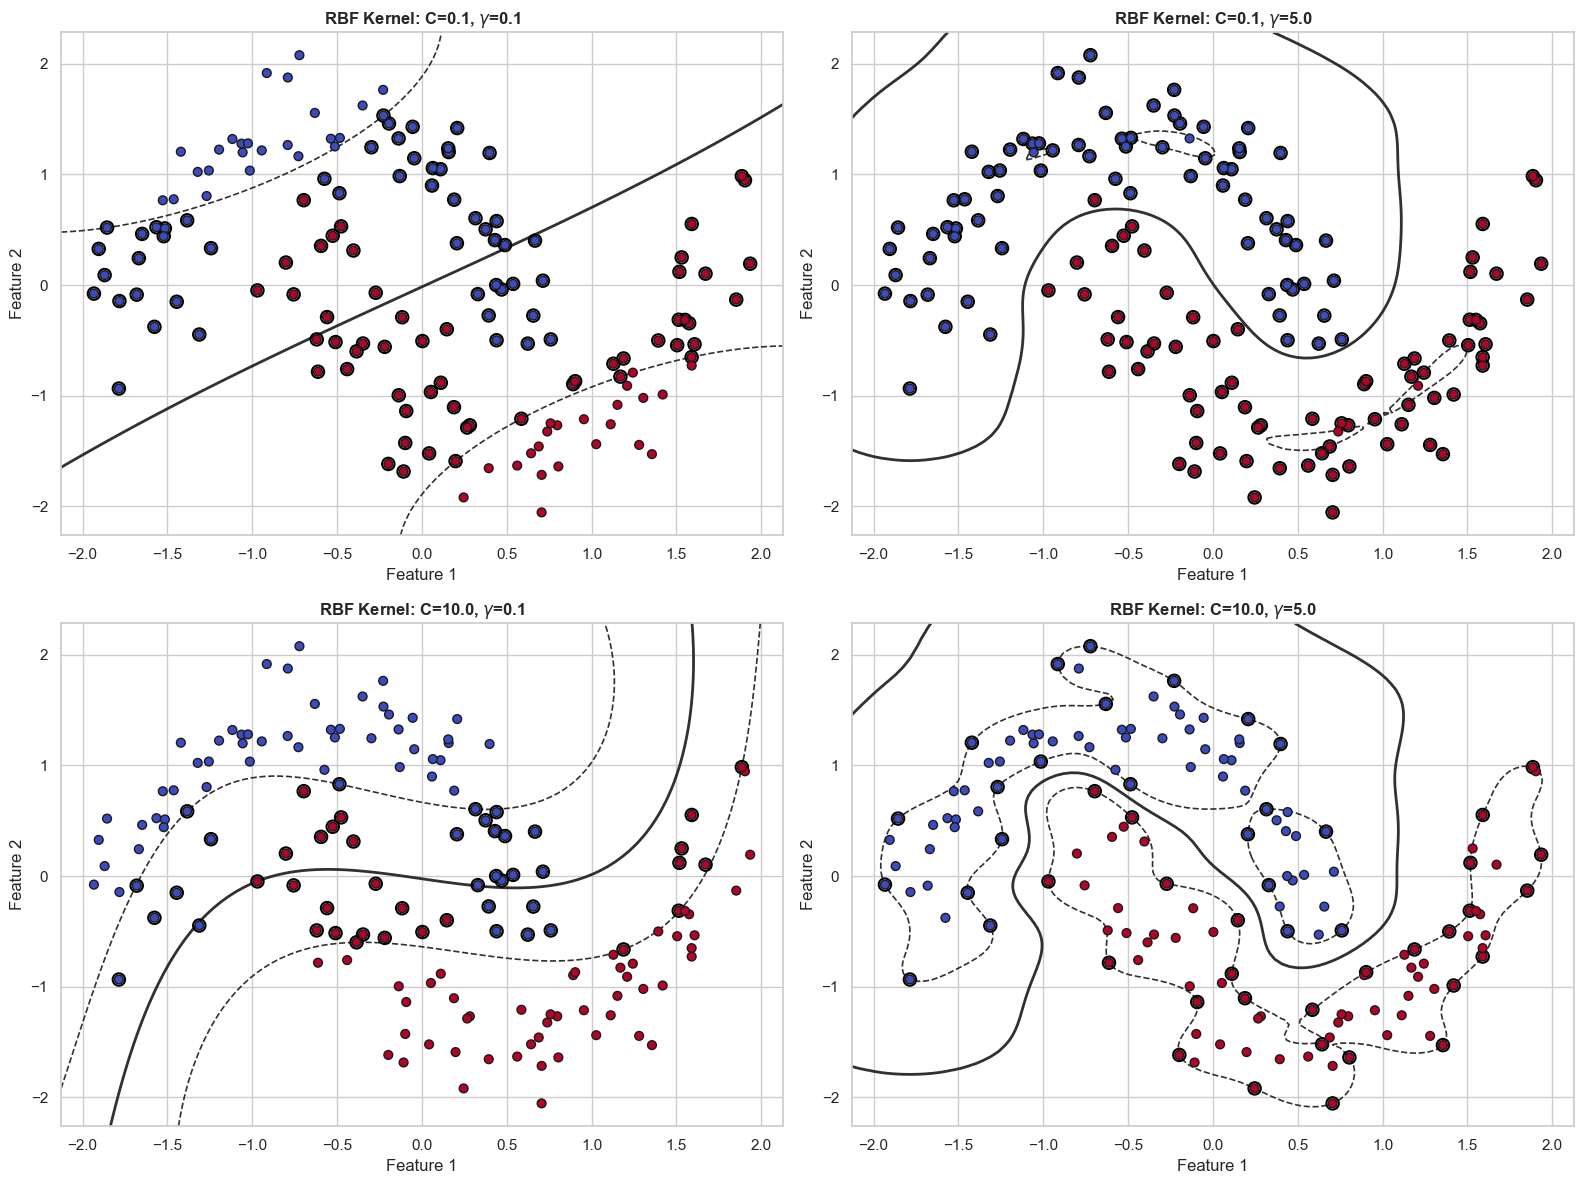

In [6]:
# Define hyperparameter grid
c_values = [0.1, 10.0]
gamma_values = [0.1, 5.0]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for i, C in enumerate(c_values):
    for j, gamma in enumerate(gamma_values):
        # Train model
        clf = SVC(kernel='rbf', C=C, gamma=gamma)
        clf.fit(X_moon_std, y_moon)
        
        # Plotting on the respective subplot
        ax = axes[i, j]
        
        # Scatter plot of training points
        scatter = ax.scatter(X_moon_std[:, 0], X_moon_std[:, 1], c=y_moon, cmap='coolwarm', edgecolors='k', s=40, zorder=3)
        
        # Meshgrid
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        xx = np.linspace(xlim[0], xlim[1], 100)
        yy = np.linspace(ylim[0], ylim[1], 100)
        YY, XX = np.meshgrid(yy, xx)
        xy = np.vstack([XX.ravel(), YY.ravel()]).T
        
        # Decision boundary contours
        Z = clf.decision_function(xy).reshape(XX.shape)
        ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.9,
                   linestyles=['--', '-', '--'], linewidths=[1.2, 2.0, 1.2])
        
        # Show support vectors
        sv = clf.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], s=80, facecolors='none', edgecolors='black', linewidths=1.5, zorder=2)
        
        ax.set_title(f"RBF Kernel: C={C}, $\gamma$={gamma}", fontsize=12, fontweight='bold')
        ax.set_xlabel('Feature 1')
        ax.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

## 8. Summary of Support Vector Machines

### 8.1 Key Takeaways
- **Hyperplane and Margins**: The goal is to maximize the margin ($2/\|w\|_2$) which acts as a safety buffer for classification confidence.
- **Support Vectors**: These are critical instances lying on or violating the margins. Modifying any other points in the training set has no effect on the final boundary.
- **Kernel Trick**: Allows non-linear classification without explicitly transforming data to higher dimensions, preserving computational efficiency.

### 8.2 Strengths & Weaknesses
| Strengths | Weaknesses |
| :--- | :--- |
| **High Dimensionality**: Extremely effective in high-dimensional spaces (even when $d > n$). | **Outlier Sensitivity**: Heavily impacted by noise and overlapping classes. |
| **Memory Efficient**: Only a subset of training points (support vectors) are stored in memory. | **Scalability**: Training time scales quadratically to cubically with the number of samples ($\mathcal{O}(n^2 \cdot d)$ to $\mathcal{O}(n^3 \cdot d)$). |
| **Versatility**: Different kernel functions can be specified to model complex boundaries. | **No Probability Estimates**: Does not directly provide probability estimates (requires computationally expensive Platt scaling). |